# Step 00: Confronto tra Estrazione Automatica (OSMnx) e Dataset Pulito

Estrarre una rete metropolitana con `OSMnx` è molto elegante, ma poiché la libreria nasce principalmente per le reti stradali, estrarre i binari ferroviari/sotterranei richiede l'uso di un **filtro personalizzato (*custom filter*)**.

Di seguito trovi lo snippet di codice pronto all'uso per scaricare la metropolitana di Londra in L-Space e i trucchi fondamentali per evitare che l'analisi fallisca.

In [1]:
import osmnx as ox
import networkx as nx

# TRUCCO 1: Configura OSMnx per scaricare i tag utili per le stazioni
# Di default OSMnx ignora i dettagli delle infrastrutture ferroviarie sui nodi
ox.settings.useful_tags_way += ['railway', 'tunnel', 'layer']
ox.settings.useful_tags_node += ['railway', 'station', 'name']

# 1. Definiamo l'area e il filtro per prendere SOLO la metropolitana (Subway)
place_name = "Greater London, United Kingdom"
subway_filter = '["railway"~"subway"]'

print("Scaricando la rete metropolitana...")
# 2. Scarichiamo il grafo usando il filtro personalizzato
# Impostiamo retain_all=True per non perdere i segmenti isolati o periferici
G_raw = ox.graph_from_place(
    place_name, 
    custom_filter=subway_filter, 
    retain_all=True, 
    simplify=True
)

print(f"Grafo raw scaricato: {len(G_raw.nodes)} nodi e {len(G_raw.edges)} archi.")

Scaricando la rete metropolitana...


Grafo raw scaricato: 2369 nodi e 5305 archi.


---

### I 4 Trucchi Accademici per non sbagliare lo studio

Quando scaricherai questi dati, ti accorgerai che OpenStreetMap (OSM) ragiona da geografo, mentre voi dovete ragionare da matematici/ingegneri. Ecco le trappole da evitare:

#### 1. Il problema del "Multi-Grafo" (`nx.MultiDiGraph`)

OSMnx restituisce un `MultiDiGraph` orientato. Questo significa che tra la stazione A e la stazione B potrebbero esserci due archi distinti (uno per l'andata e uno per il ritorno), oppure archi multipli se passano linee diverse sugli stessi binari.

* **Cosa fare:** Per fare un'analisi di resilienza classica (stress-test), vi conviene convertire il grafo in un **grafo semplice non orientato**.

In [2]:
# Converte in grafo non orientato eliminando i doppi archi paralleli
G = nx.Graph(G_raw)
print(f"Grafo convertito a semplice non orientato: {len(G.nodes)} nodi e {len(G.edges)} archi.")

Grafo convertito a semplice non orientato: 2369 nodi e 2905 archi.


#### 2. Il tranello delle stazioni "spezzettate" (Data Cleaning obbligatorio)

In OpenStreetMap, una stazione grande (es. *King's Cross*) non è quasi mai un singolo nodo. Spesso è mappata con un nodo per ogni banchina (Platform 1, Platform 2) o per ogni linea che vi incrocia.
Se calcolate la Betweenness Centrality così, i flussi si divideranno su nodi vicini falsando i picchi.



* **Il Trucco:** Dovete fondere (*consolidate*) i nodi che si riferiscono alla stessa stazione georeferenziata. Potete farlo combinando la vicinanza spaziale (es. nodi a meno di 100-150 metri) oppure aggregandoli per il tag `name`.

In [3]:
# OSMnx ha una funzione nativa per consolidare intersezioni/nodi vicini
G_projected = ox.project_graph(G_raw) # Proietta in metri per calcolare le distanze reali
G_clean = ox.consolidate_intersections(G_projected, rebuild_graph=True, tolerance=150, dead_ends=False)
print(f"Grafo consolidato (150m): {len(G_clean.nodes)} nodi e {len(G_clean.edges)} archi.")

Grafo consolidato (150m): 163 nodi e 358 archi.


*Nota: se usi `consolidate_intersections`, OSMnx unisce i nodi geometricamente vicini creando un grafo topologicamente pulito, perfetto per l'L-Space.*

#### 3. Gestire le componenti isolate prima dello Stress-Test

Quando calcolate l'Average Path Length per dimostrare l'effetto Small-World, la formula di NetworkX vi restituirà un errore se la rete è disconnessa (ovvero se ci sono stazioni isolate o micro-linee staccate dal blocco principale).

* **Il Trucco:** Isolate la **Componente Gigante** (*Giant Component*) prima di lanciare i calcoli macro.

In [4]:
# Prendi solo la componente principale connessa
giant_component = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component).copy()

# Ora puoi calcolare l'Average Path Length in sicurezza
avg_path = nx.average_shortest_path_length(G_giant)
print(f"Average Path Length della Componente Gigante: {avg_path:.4f}")

Average Path Length della Componente Gigante: 41.9195


#### 4. Come plottare i risultati dello Stress-Test

Giallorenzo apprezzerà moltissimo l'aspetto visivo. Quando simulate l'attacco mirato (es. eliminate il 5% dei nodi a Betweenness più alta), non limitatevi a mostrare un grafico cartesiano, ma mostrate la mappa che si "spegne".
Visto che i nodi di OSMnx mantengono le coordinate geografiche (`x` e `y`), potete usare `ox.plot_graph` per mostrare visivamente la rete che si frammenta.

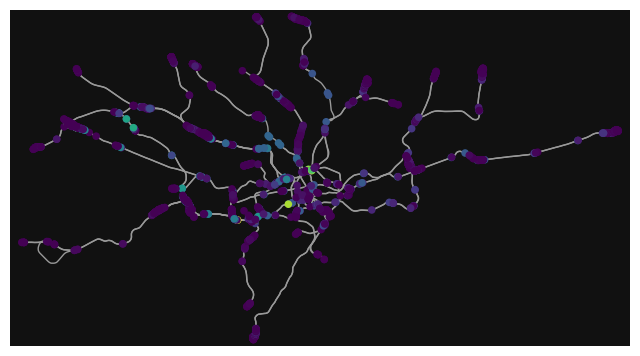

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
# Esempio visivo: colorare i nodi in base alla Betweenness
betweenness = nx.betweenness_centrality(G_giant)
# Crei una lista di colori basata sul valore di Betweenness
node_colors = [betweenness[node] for node in G_giant.nodes()]

# Disegna la mappa con OSMnx usando la mappa di calore
# Convertiamo in MultiGraph per compatibilita' con il plotter di OSMnx 2.x
ox.plot_graph(nx.MultiGraph(G_giant), node_color=node_colors, node_size=30, edge_linewidth=1)

---

### Confronto delle Statistiche di Rete

Confrontiamo le statistiche ottenute da OSMnx (Raw e Clean) con quelle del **dataset pulito (Hennig & O'Brien)** per evidenziare l'effetto del consolidamento e della pulizia topologica.

In [6]:
import sys
sys.path.append('..')
from src.data_loader import load_london_network

G_curated, _, _, _ = load_london_network()

print("="*60)
print(f"{'Metrica':<30}{'OSM Raw':<10}{'OSM Clean':<10}{'Dataset Curato':<15}")
print("="*60)

# Calcoliamo le metriche
print(f"{'Nodi totali':<30}{len(G.nodes):<10}{len(G_clean.nodes):<10}{len(G_curated.nodes):<15}")
print(f"{'Archi totali':<30}{len(G.edges):<10}{len(G_clean.edges):<10}{len(G_curated.edges):<15}")

# Componente Gigante
comp_osm_raw = max(nx.connected_components(G), key=len)
G_g_raw = G.subgraph(comp_osm_raw)

comp_osm_clean = max(nx.connected_components(nx.Graph(G_clean)), key=len)
G_g_clean = nx.Graph(G_clean).subgraph(comp_osm_clean)

print(f"{'Nodi Comp. Gigante':<30}{len(G_g_raw.nodes):<10}{len(G_g_clean.nodes):<10}{len(G_curated.nodes):<15}")
print(f"{'Avg Path Length (Giant)':<30}{nx.average_shortest_path_length(G_g_raw):.4f}    {nx.average_shortest_path_length(G_g_clean):.4f}    {nx.average_shortest_path_length(G_curated):.4f}")
print(f"{'Global Transitivity':<30}{nx.transitivity(G):.4f}    {nx.transitivity(nx.Graph(G_clean)):.4f}    {nx.transitivity(G_curated):.4f}")
print("="*60)

Metrica                       OSM Raw   OSM Clean Dataset Curato 
Nodi totali                   2369      163       302            
Archi totali                  2905      358       349            
Nodi Comp. Gigante            2267      159       302            


Avg Path Length (Giant)       41.9195    11.9826    14.0985
Global Transitivity           0.0758    0.0701    0.0546
